In [3]:
import pandas as pd
import numpy as np


In [4]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look better
sns.set(style="whitegrid")

In [8]:
file_path = "electric_vehicle_market_trends_50000_rows 4321.xlsx"

df = pd.read_excel(file_path)

# Preview data
df.head()

,date,country,ev_units_sold,ev_market_share_percent,battery_cost_per_kwh,charging_stations,fast_chargers,fuel_price,govt_subsidy,carbon_emission_reduction_tons,interest_rate,next_month_ev_sales,sales_trend
0,2018-12-01,Japan,109009,22.94,165.09,51436,74967,169.44,1335.29,215678.51,8.47,238017.0,Growth
1,2020-09-01,UK,238017,7.44,195.81,44513,66295,123.32,2188.68,172452.08,7.95,145227.0,Decline
2,2017-02-01,India,145227,13.65,136.82,234853,20589,127.85,5304.25,28635.74,5.35,171500.0,Growth
3,2024-11-01,India,171500,14.41,151.83,38060,69353,64.18,6153.80,587244.10,9.54,24081.0,Decline
4,2020-08-01,USA,24081,39.73,92.78,141191,112365,110.87,4688.31,352637.04,9.84,148743.0,Growth


In [9]:
# Check shape
print("Shape:", df.shape)

# Column info
df.info()

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Statistical summary
df.describe()

Shape: (50000, 13)
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            50000 non-null  datetime64[us]
 1   country                         50000 non-null  str           
 2   ev_units_sold                   50000 non-null  int64         
 3   ev_market_share_percent         50000 non-null  float64       
 4   battery_cost_per_kwh            50000 non-null  float64       
 5   charging_stations               50000 non-null  int64         
 6   fast_chargers                   50000 non-null  int64         
 7   fuel_price                      50000 non-null  float64       
 8   govt_subsidy                    50000 non-null  float64       
 9   carbon_emission_reduction_tons  50000 non-null  float64       
 10  interest_rate                   50000 non-null  float64       

,date,ev_units_sold,ev_market_share_percent,battery_cost_per_kwh,charging_stations,fast_chargers,fuel_price,govt_subsidy,carbon_emission_reduction_tons,interest_rate,next_month_ev_sales
count,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,49999.000000
mean,2019-12-10 14:55:39.071999,127791.378780,23.128250,145.160532,125642.933840,60164.539700,120.124021,4244.231136,451243.305711,6.513267,127791.754435
min,2015-01-01 00:00:00,5025.000000,1.000000,90.000000,1005.000000,203.000000,60.000000,500.250000,1000.040000,3.000000,5025.000000
25%,2017-06-01 00:00:00,66439.250000,12.260000,117.720000,63302.000000,30011.000000,90.040000,2378.052500,228559.222500,4.770000,66438.500000
50%,2019-12-01 00:00:00,127847.500000,23.140000,145.290000,125960.000000,60268.500000,120.125000,4234.300000,451037.545000,6.510000,127853.000000
75%,2022-06-01 00:00:00,189221.750000,34.110000,172.620000,187792.250000,90146.250000,149.960000,6128.067500,675442.830000,8.270000,189223.500000
max,2024-12-01 00:00:00,249999.000000,45.000000,200.000000,249995.000000,119999.000000,180.000000,7999.380000,899984.470000,10.000000,249999.000000
std,NaN,70758.556921,12.672175,31.699812,71815.817638,34606.936066,34.661334,2165.171487,259381.457677,2.018853,70759.214672


In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.dropna(inplace=True)

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [13]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\pc\AppData\Local\Temp\ipykernel_12608\1664106601.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [14]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [15]:
# Replace 'date_column_name' with actual column name
# df['date_column_name'] = pd.to_datetime(df['date_column_name'])

In [21]:
df.drop_duplicates(inplace=True)

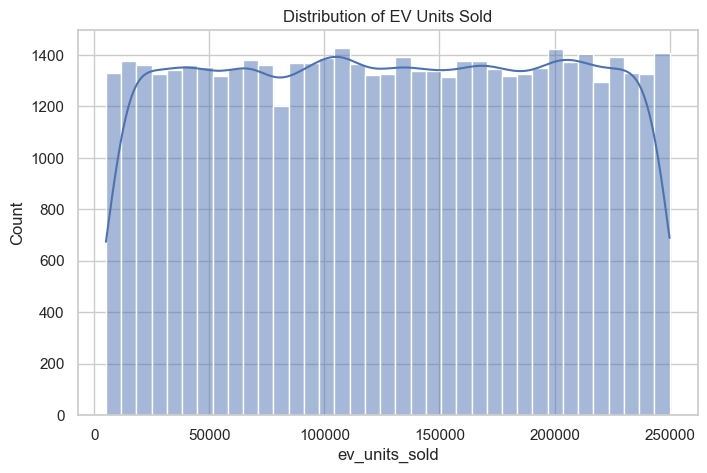

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['ev_units_sold'], kde=True)
plt.title("Distribution of EV Units Sold")
plt.show()

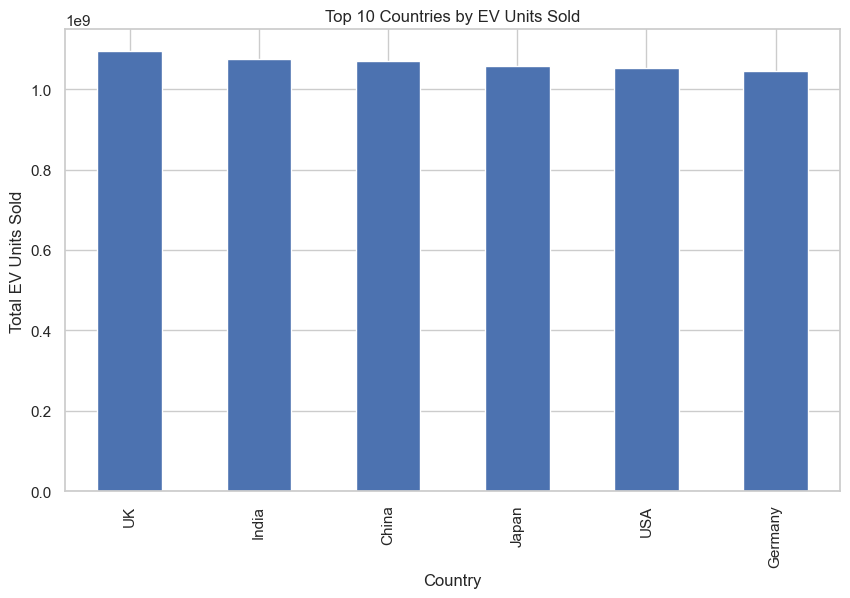

In [25]:
plt.figure(figsize=(10,6))

top_countries = df.groupby('country')['ev_units_sold'].sum().sort_values(ascending=False).head(10)

top_countries.plot(kind='bar')

plt.title("Top 10 Countries by EV Units Sold")
plt.ylabel("Total EV Units Sold")
plt.xlabel("Country")
plt.show()

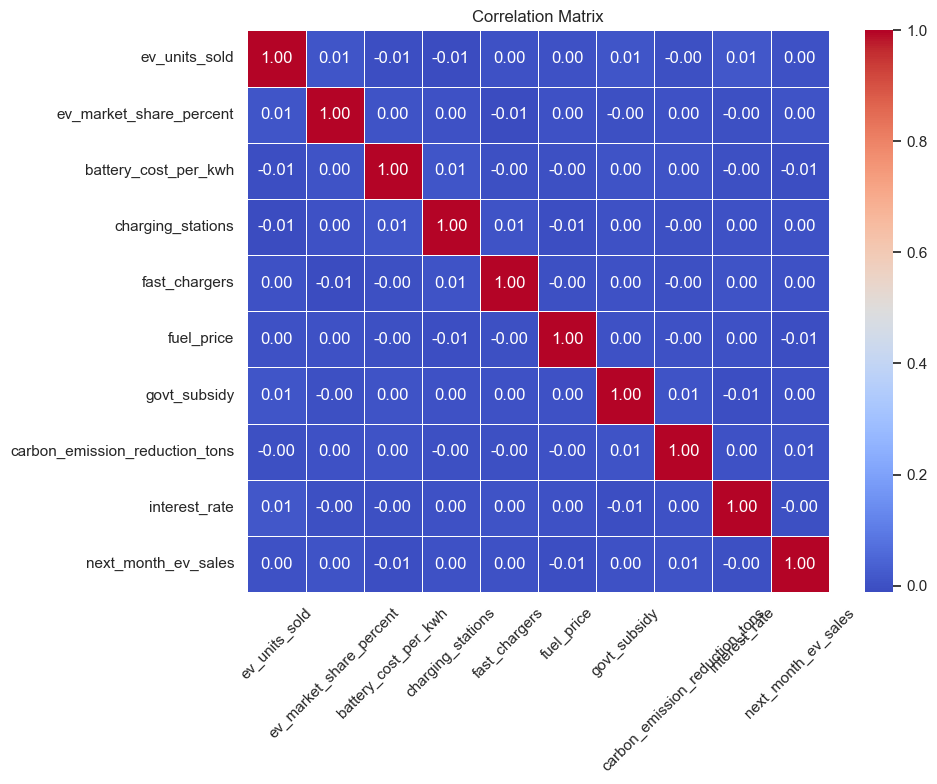

In [26]:
plt.figure(figsize=(10,8))

# Select only numeric columns explicitly
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

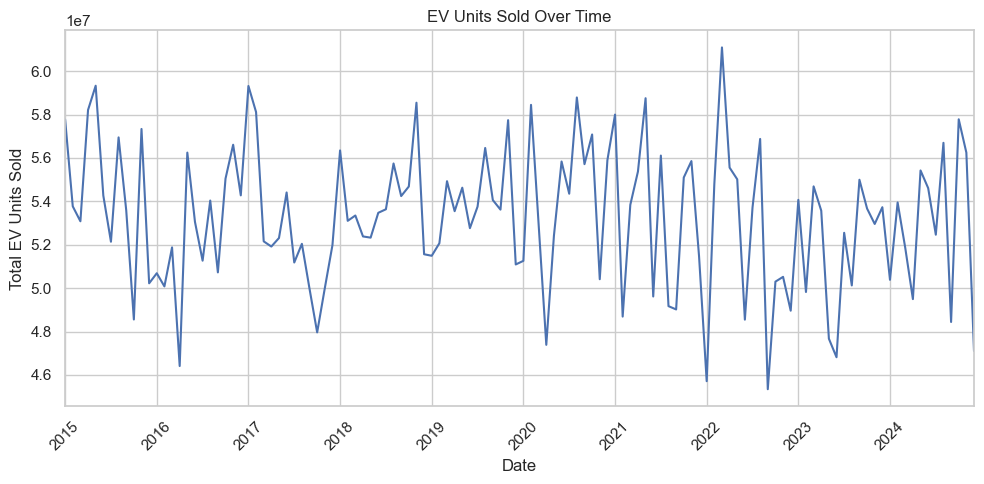

In [28]:
# Convert date column to datetime (VERY important)
df['date'] = pd.to_datetime(df['date'])

# Group by date and sum EV units sold
df_grouped = df.groupby('date')['ev_units_sold'].sum()

plt.figure(figsize=(10,5))
df_grouped.plot()

plt.title("EV Units Sold Over Time")
plt.ylabel("Total EV Units Sold")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
# Convert to datetime safely
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Drop rows where date conversion failed
df = df.dropna(subset=['date'])

# Sort by date (important for time series)
df = df.sort_values('date')

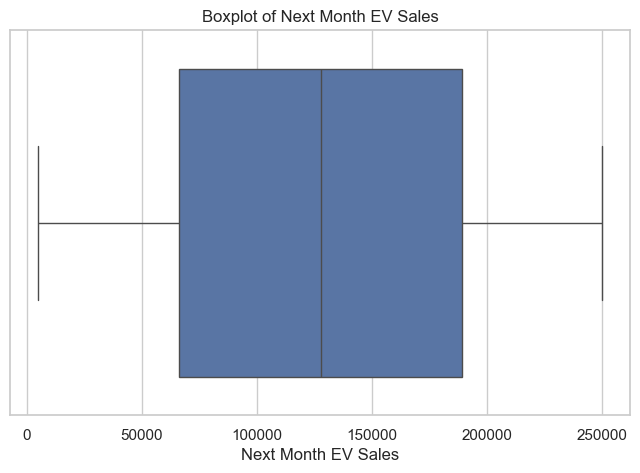

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['next_month_ev_sales'])
plt.title("Boxplot of Next Month EV Sales")
plt.xlabel("Next Month EV Sales")
plt.show()

In [31]:
df.to_excel("cleaned_ev_dataset.xlsx", index=False)